# Project 1: Comparing Arrival Delays for Alaska and AM West

**Sebastian Perdomo | IS 362**

This notebook compares arrival delays for two airlines across five cities.

## 1. Load and clean the data

Drop the blank row, fill the missing airline names down from the row above, and
convert the counts back to whole numbers.

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

raw = pd.read_csv("airline_delays.csv", thousands=",")

df = raw.dropna(how="all").copy()
df["Airline"] = df["Airline"].ffill()

cities = df.columns[2:]
df[cities] = df[cities].astype(int)
df

,Airline,Status,Los Angeles,Phoenix,San Diego,San Francisco,Seattle
0,ALASKA,on time,497,221,212,503,1841
1,ALASKA,delayed,62,12,20,102,305
3,AM WEST,on time,694,4840,383,320,201
4,AM WEST,delayed,117,415,65,129,61


## 2. Reshape the data

`melt()` turns the city columns into rows. `pivot_table()` then gives one row per
airline and city, with on-time and delayed counts side by side.

In [2]:
long = df.melt(id_vars=["Airline", "Status"], var_name="City", value_name="Flights")

flights = (long
           .pivot_table(index=["Airline", "City"], columns="Status",
                        values="Flights", aggfunc="sum")
           .reset_index()
           .rename(columns={"on time": "On Time", "delayed": "Delayed"}))
flights.columns.name = None
flights = flights[["Airline", "City", "On Time", "Delayed"]]

flights["Total"] = flights["On Time"] + flights["Delayed"]
flights["Delay Rate"] = flights["Delayed"] / flights["Total"]
flights.style.format({"Delay Rate": "{:.1%}", "On Time": "{:,}",
                      "Delayed": "{:,}", "Total": "{:,}"})

,Airline,City,On Time,Delayed,Total,Delay Rate
0,ALASKA,Los Angeles,497,62,559,11.1%
1,ALASKA,Phoenix,221,12,233,5.2%
2,ALASKA,San Diego,212,20,232,8.6%
3,ALASKA,San Francisco,503,102,605,16.9%
4,ALASKA,Seattle,"1,841",305,"2,146",14.2%
5,AM WEST,Los Angeles,694,117,811,14.4%
6,AM WEST,Phoenix,"4,840",415,"5,255",7.9%
7,AM WEST,San Diego,383,65,448,14.5%
8,AM WEST,San Francisco,320,129,449,28.7%
9,AM WEST,Seattle,201,61,262,23.3%


## 3. Overall delay rate by airline

Across all five cities combined, AM West has the lower delay rate.

In [3]:
overall = flights.groupby("Airline")[["On Time", "Delayed", "Total"]].sum()
overall["Delay Rate"] = overall["Delayed"] / overall["Total"]
overall.style.format({"Delay Rate": "{:.1%}", "On Time": "{:,}",
                      "Delayed": "{:,}", "Total": "{:,}"})

,On Time,Delayed,Total,Delay Rate
Airline,,,,
ALASKA,"3,274",501,"3,775",13.3%
AM WEST,"6,438",787,"7,225",10.9%


## 4. Delay rate by city

City by city, Alaska has the lower delay rate in all five.

In [4]:
by_city = flights.pivot(index="City", columns="Airline", values="Delay Rate")
by_city["Lower Delay Rate"] = by_city.idxmin(axis=1)
by_city.style.format({"ALASKA": "{:.1%}", "AM WEST": "{:.1%}"})

Airline,ALASKA,AM WEST,Lower Delay Rate
City,,,
Los Angeles,11.1%,14.4%,ALASKA
Phoenix,5.2%,7.9%,ALASKA
San Diego,8.6%,14.5%,ALASKA
San Francisco,16.9%,28.7%,ALASKA
Seattle,14.2%,23.3%,ALASKA


## 5. Why the results disagree

The two airlines fly to different places. Most AM West flights land in Phoenix,
the city with the fewest delays. Most Alaska flights land in Seattle, where
delays are more common. Those volumes pull each airline's overall rate toward
its busiest city.

In [5]:
share = flights.pivot(index="City", columns="Airline", values="Total")
share = share / share.sum()
share.style.format("{:.1%}")

Airline,ALASKA,AM WEST
City,,
Los Angeles,14.8%,11.2%
Phoenix,6.2%,72.7%
San Diego,6.1%,6.2%
San Francisco,16.0%,6.2%
Seattle,56.8%,3.6%


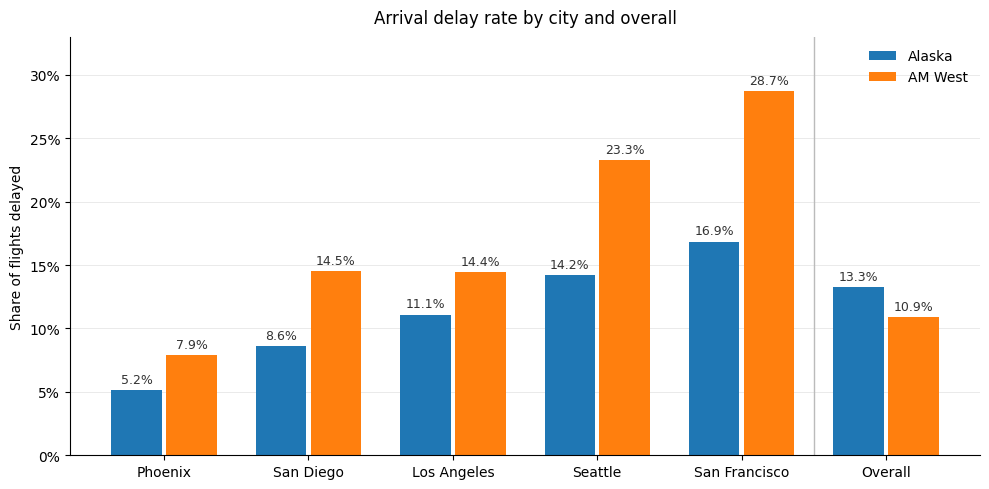

In [6]:
city_order = ["Phoenix", "San Diego", "Los Angeles", "Seattle", "San Francisco"]
plot_data = by_city.loc[city_order, ["ALASKA", "AM WEST"]]
plot_data.loc["Overall"] = overall["Delay Rate"]

colors = {"ALASKA": "#1f77b4", "AM WEST": "#ff7f0e"}
labels = {"ALASKA": "Alaska", "AM WEST": "AM West"}
x = range(len(plot_data))
width = 0.38

fig, ax = plt.subplots(figsize=(10, 5))
for i, airline in enumerate(["ALASKA", "AM WEST"]):
    positions = [p + (i - 0.5) * width for p in x]
    bars = ax.bar(positions, plot_data[airline], width=width - 0.03,
                  color=colors[airline], label=labels[airline])
    ax.bar_label(bars, labels=[f"{v:.1%}" for v in plot_data[airline]],
                 padding=3, fontsize=9, color="#333333")

ax.axvline(len(plot_data) - 1.5, color="#bbbbbb", linewidth=1)
ax.set_xticks(list(x))
ax.set_xticklabels(plot_data.index)
ax.set_ylabel("Share of flights delayed")
ax.yaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
ax.set_ylim(0, 0.33)
ax.set_title("Arrival delay rate by city and overall", fontsize=12, pad=10)
ax.legend(frameon=False)
ax.grid(axis="y", alpha=0.3, linewidth=0.6)
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

## Conclusion

Alaska has a lower delay rate than AM West in every city, yet AM West has the
lower delay rate overall, 10.9% against 13.3%. This is Simpson's paradox. AM West
flies mostly into Phoenix, which has few delays, while Alaska flies mostly into
Seattle and San Francisco, which have more.

Comparing the airlines on the overall number alone would point to the wrong
answer. Compared city by city on the same routes, Alaska arrives on time more
often.